In [1]:
import sys
import os
sys.path.insert(0, '..')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import load_and_clean, build_pipeline, NUMERIC_COLS, CATEGORICAL_COLS
from src.features import add_features

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Phase 1: Exploratory Data Analysis

In [3]:
df_raw = pd.read_csv('../data/telco_churn.csv')
print(df_raw.shape)
df_raw.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


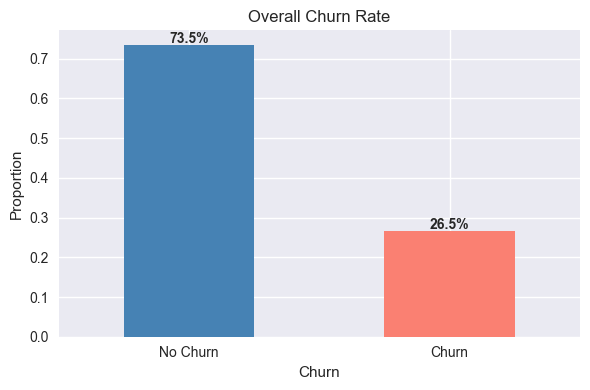

In [5]:
churn_rate = df_raw['Churn'].value_counts(normalize=True)
print(churn_rate)

fig, ax = plt.subplots(figsize=(6, 4))
churn_rate.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Overall Churn Rate')
ax.set_xlabel('Churn')
ax.set_ylabel('Proportion')
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)
for i, v in enumerate(churn_rate):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
print("Rows with blank TotalCharges:")
print(df_raw[df_raw['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'TotalCharges']])

Rows with blank TotalCharges:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


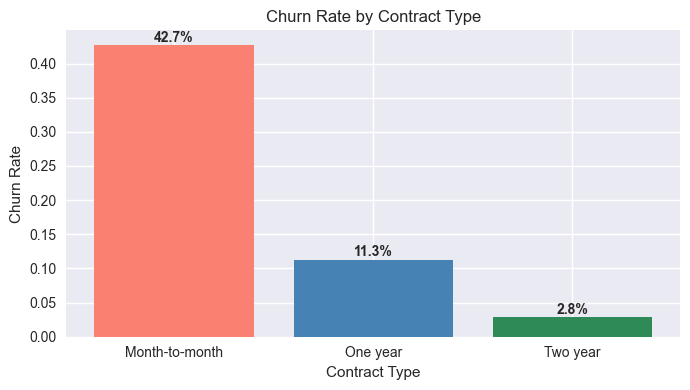

In [7]:
contract_churn = df_raw.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(contract_churn['Contract'], contract_churn['ChurnRate'], color=['salmon', 'steelblue', 'seagreen'])
ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate')
for i, row in contract_churn.iterrows():
    ax.text(i, row['ChurnRate'] + 0.005, f"{row['ChurnRate']:.1%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

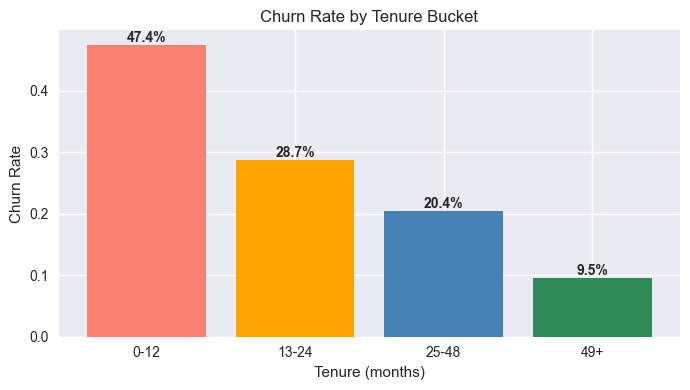

In [8]:
df_raw['tenure_bucket'] = pd.cut(
    df_raw['tenure'],
    bins=[0, 12, 24, 48, float('inf')],
    labels=['0-12', '13-24', '25-48', '49+'],
    include_lowest=True
)
tenure_churn = df_raw.groupby('tenure_bucket')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()
tenure_churn.columns = ['tenure_bucket', 'ChurnRate']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tenure_churn['tenure_bucket'].astype(str), tenure_churn['ChurnRate'],
       color=['salmon', 'orange', 'steelblue', 'seagreen'])
ax.set_title('Churn Rate by Tenure Bucket')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Churn Rate')
for i, row in tenure_churn.iterrows():
    ax.text(i, row['ChurnRate'] + 0.005, f"{row['ChurnRate']:.1%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

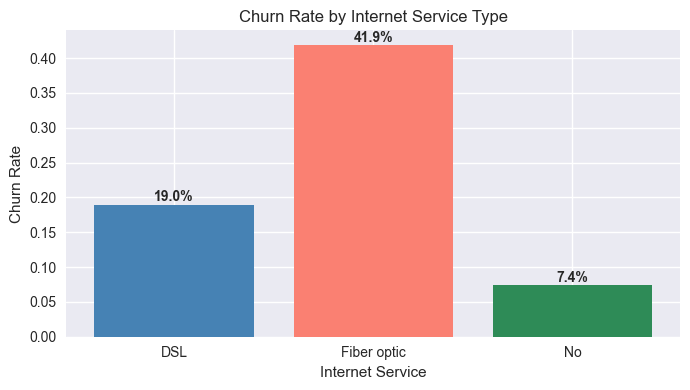

In [9]:
internet_churn = df_raw.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()
internet_churn.columns = ['InternetService', 'ChurnRate']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(internet_churn['InternetService'], internet_churn['ChurnRate'],
       color=['steelblue', 'salmon', 'seagreen'])
ax.set_title('Churn Rate by Internet Service Type')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate')
for i, row in internet_churn.iterrows():
    ax.text(i, row['ChurnRate'] + 0.005, f"{row['ChurnRate']:.1%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

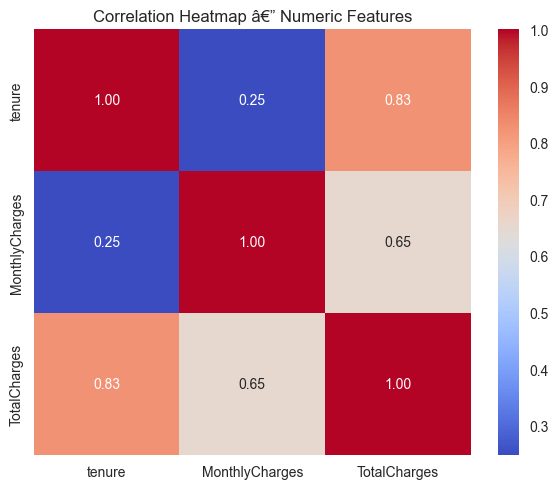

In [10]:
corr_data = df_raw[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr_data['TotalCharges'] = pd.to_numeric(corr_data['TotalCharges'], errors='coerce')
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap â€” Numeric Features')
plt.tight_layout()
plt.show()

**EDA Checkpoint:** Customers most likely to churn: month-to-month contracts, tenure < 12 months, high MonthlyCharges, Fiber optic internet, no tech support.

# Phase 2 & 3: Cleaning, Preprocessing & Feature Engineering

In [11]:
# Use src/ functions â€” no inline duplication
df = load_and_clean('../data/telco_churn.csv')
df = add_features(df)
print(df.shape)
df.head()

(7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,num_services,avg_monthly_spend,has_streaming
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12,1,14.925000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,25-48,3,53.985714,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12,3,36.050000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48,3,40.016304,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12,1,50.550000,0


In [12]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Churn rate train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

X_train: (5634, 23), X_test: (1409, 23)
Churn rate train: 0.265, test: 0.265


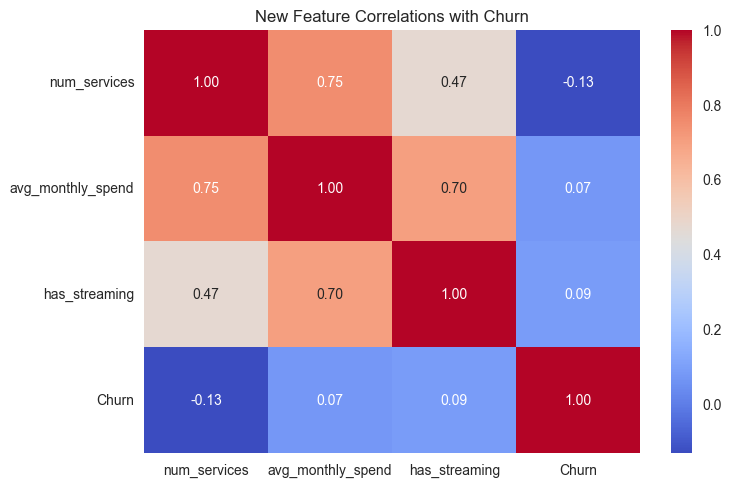

In [13]:
# Feature correlation check for new features
df_corr = df[['num_services', 'avg_monthly_spend', 'has_streaming', 'Churn']].corr()
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('New Feature Correlations with Churn')
plt.show()

# Phase 4: Handling Class Imbalance

In [14]:
print(f"Class distribution: {y_train.value_counts().to_dict()}")
print(f"Churn rate: {y_train.mean():.3f}")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Class distribution: {0: 4139, 1: 1495}
Churn rate: 0.265
scale_pos_weight: 2.769


In [15]:
# Build a simple pipeline for SMOTE comparison (uses default XGB in build_pipeline)
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Fit preprocessor to get encoded data for SMOTE
preprocessor_only = build_pipeline().named_steps['preprocessor']
preprocessor_only.fit(X_train)
X_train_enc = preprocessor_only.transform(X_train)
X_test_enc = preprocessor_only.transform(X_test)

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

xgb_smote = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = xgb_smote.predict(X_test_enc)
print("SMOTE XGBoost:\n", classification_report(y_test, y_pred_smote))

SMOTE XGBoost:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85      1035
           1       0.59      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



**Decision:** Using class weights (scale_pos_weight) in the deployed model â€” simpler, no risk of SMOTE leakage at inference time. Performance is comparable on this dataset.

# Phase 5: Modeling â€” Baseline to XGBoost

In [16]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_pipeline = build_pipeline(model=lr)
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC AUC: 0.8456


In [17]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_pipeline = build_pipeline(model=rf)
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC AUC: 0.8228


In [18]:
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_pipeline = build_pipeline(model=xgb_model)
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.53      0.65      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409

ROC AUC: 0.8217


# Phase 6: Hyperparameter Tuning (XGBoost)

In [19]:
param_grid = {
    'model__max_depth': [3, 5, 7],
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_pipeline_tune = build_pipeline(model=xgb_base)

grid = GridSearchCV(
    xgb_pipeline_tune,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

best_pipeline = grid.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test)
y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]
print("\nTuned XGBoost:")
print(classification_report(y_test, y_pred_tuned))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300}
Best CV F1: 0.6329

Tuned XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC AUC: 0.8424


# Phase 7: Evaluation Deep-Dive

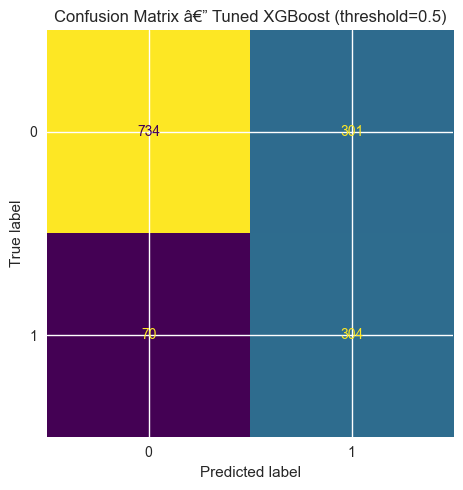

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix â€” Tuned XGBoost (threshold=0.5)')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

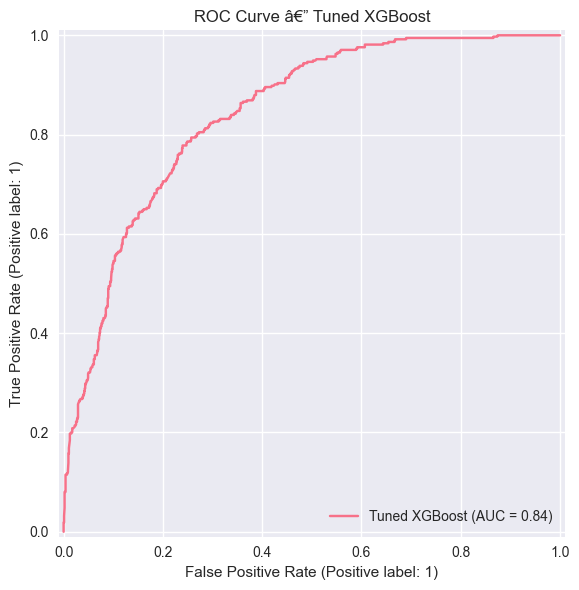

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_tuned, ax=ax, name='Tuned XGBoost')
ax.set_title('ROC Curve â€” Tuned XGBoost')
plt.tight_layout()
plt.savefig('../notebooks/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("Threshold Analysis:")
print("-" * 60)
for thresh in [0.3, 0.35, 0.5]:
    y_thresh = (y_prob_tuned >= thresh).astype(int)
    print(f"\nThreshold = {thresh}")
    print(classification_report(y_test, y_thresh, target_names=['No Churn', 'Churn']))

Threshold Analysis:
------------------------------------------------------------

Threshold = 0.3
              precision    recall  f1-score   support

    No Churn       0.96      0.50      0.66      1035
       Churn       0.41      0.95      0.57       374

    accuracy                           0.62      1409
   macro avg       0.69      0.72      0.62      1409
weighted avg       0.82      0.62      0.64      1409


Threshold = 0.35
              precision    recall  f1-score   support

    No Churn       0.94      0.56      0.70      1035
       Churn       0.43      0.90      0.58       374

    accuracy                           0.65      1409
   macro avg       0.68      0.73      0.64      1409
weighted avg       0.80      0.65      0.67      1409


Threshold = 0.5
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.81      0.62       374

    accuracy                           0.74      

**Business Decision:** We lower the threshold to 0.35. Since a missed churner (false negative) costs more than a wasted retention offer (false positive), we accept lower precision in exchange for higher recall on the churn class.

# Phase 8: SHAP Interpretability

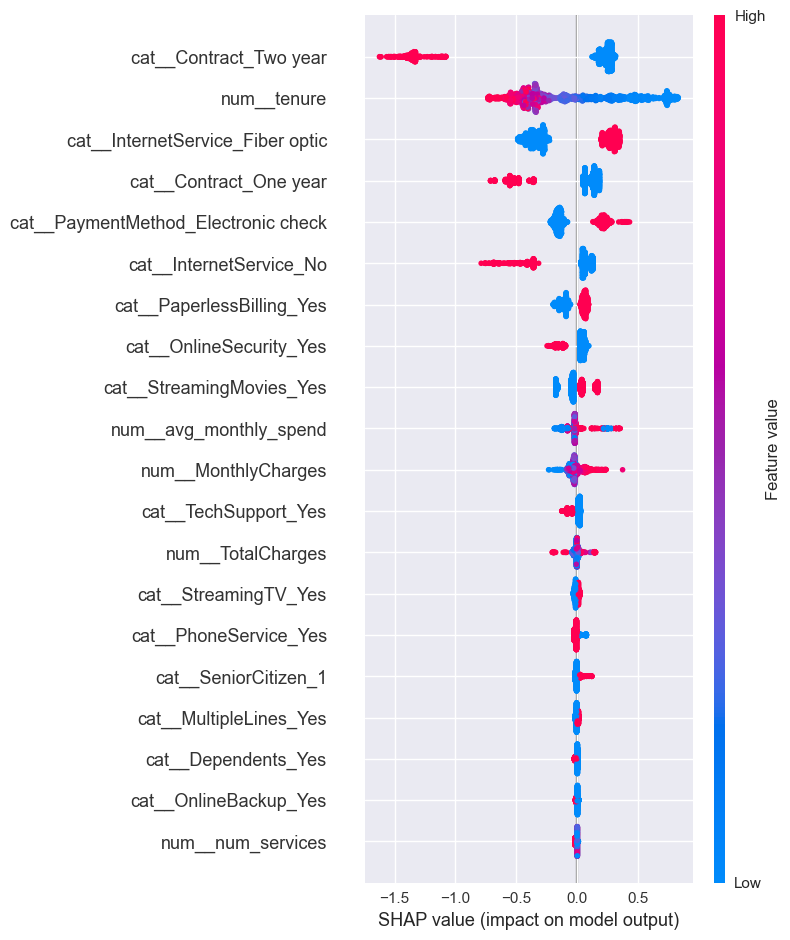

In [23]:
xgb_model_fit = best_pipeline.named_steps['model']
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(xgb_model_fit)
shap_values = explainer.shap_values(X_test_transformed)

# Global summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../notebooks/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

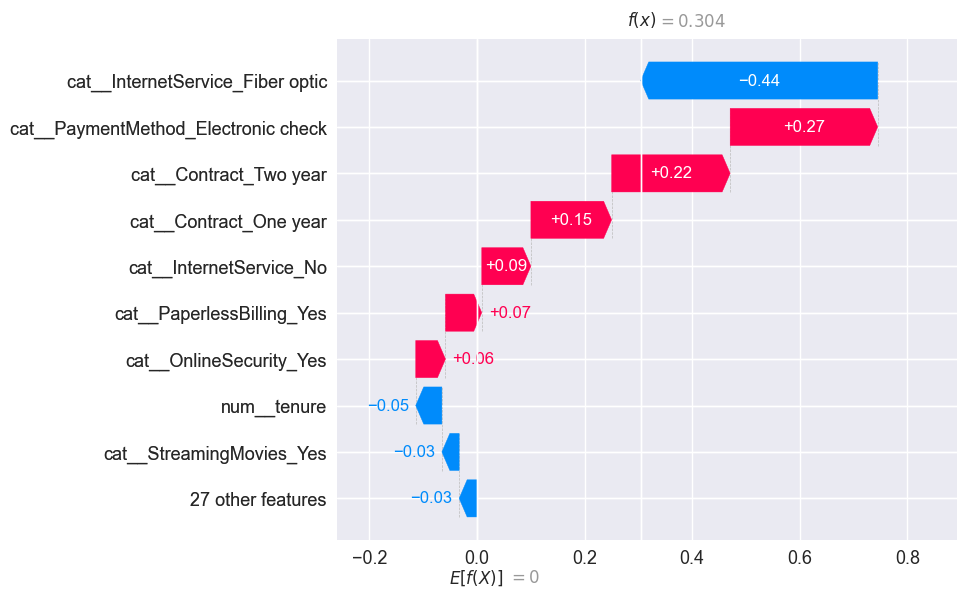

In [24]:
# Individual prediction â€” first churner in test set
churner_idx = y_test[y_test == 1].index[0]
pos = list(X_test.index).index(churner_idx)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        feature_names=list(feature_names)
    )
)

## Business Insight

Month-to-month contract, tenure < 12 months, and absence of tech support are the three strongest churn signals. High MonthlyCharges amplifies risk, while longer tenure and two-year contracts are strong retention indicators. Customers who bundle more services (higher num_services) show lower churn probability, suggesting that cross-selling reduces attrition risk.

# Save Final Model

In [25]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipeline, '../models/churn_pipeline.pkl')
print("Best pipeline saved to ../models/churn_pipeline.pkl")

Best pipeline saved to ../models/churn_pipeline.pkl
